<a href="https://colab.research.google.com/github/supreeeethh/EliteTech/blob/main/Elite_task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


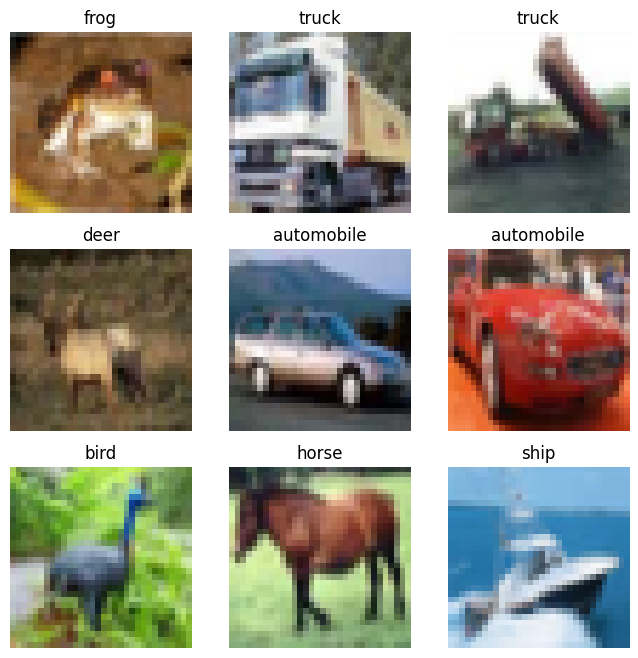

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 48ms/step - accuracy: 0.3577 - loss: 1.7233 - val_accuracy: 0.5400 - val_loss: 1.3188
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5458 - loss: 1.3064

Test Accuracy: 0.5400000214576721
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


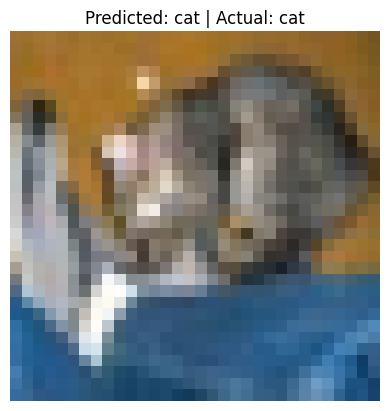

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test)
)
test_loss, test_acc = model.evaluate(x_test, y_test)
print("\nTest Accuracy:", test_acc)
predictions = model.predict(x_test)
def show_prediction(index):
    plt.imshow(x_test[index])
    plt.title("Predicted: {} | Actual: {}".format(
        class_names[np.argmax(predictions[index])],
        class_names[y_test[index][0]]
    ))
    plt.axis('off')
    plt.show()

show_prediction(0)